# 04 — Inspect Sampling Strategy

**Active Boundary Mining** — the pixel sampling engine for Stage 1.

This notebook provides a deep visual inspection of how pixels are sampled for training:

1. **Distance Transform** — how proximity to nucleus boundaries is computed
2. **Sampling Weight Maps** — how boundary pixels get boosted probability
3. **Sampled Pixel Overlay** — where exactly the sampled pixels land on real images
4. **Class Balance Analysis** — distribution of sampled labels across images
5. **Boundary vs Uniform Comparison** — why boundary mining matters

---

## 1. Setup & Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from scipy.ndimage import distance_transform_edt

from src.preprocessing.stain_normalizer import MacenkoNormalizer
from src.data.label_generator import generate_binary_labels, generate_3class_labels
from src.sampling.pixel_sampler import active_boundary_mining

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

print('Setup complete.')

Setup complete.


## 2. Load Data (Small Subset)

In [3]:
# Load a small subset via mmap to keep RAM low
images = np.load('../data/raw/Fold1/images/fold1/images.npy', mmap_mode='r')
masks  = np.load('../data/raw/Fold1/masks/fold1/masks.npy',  mmap_mode='r')

print(f'Images shape: {images.shape}')
print(f'Masks  shape: {masks.shape}')

# Pick 6 diverse sample indices for visualization
sample_indices = [100, 350, 800, 1300, 1750, 2400]
print(f'\nUsing sample indices: {sample_indices}')

Images shape: (2656, 256, 256, 3)
Masks  shape: (2656, 256, 256, 6)

Using sample indices: [100, 350, 800, 1300, 1750, 2400]


## 3. Label Generation Preview

Before inspecting sampling, let's visualize the two label modes:
- **Binary** (Exp A): 0=background, 1=nucleus
- **3-Class** (Exp B): 0=background, 1=interior, 2=boundary

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [34.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [46.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [33.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [5.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..247.0].


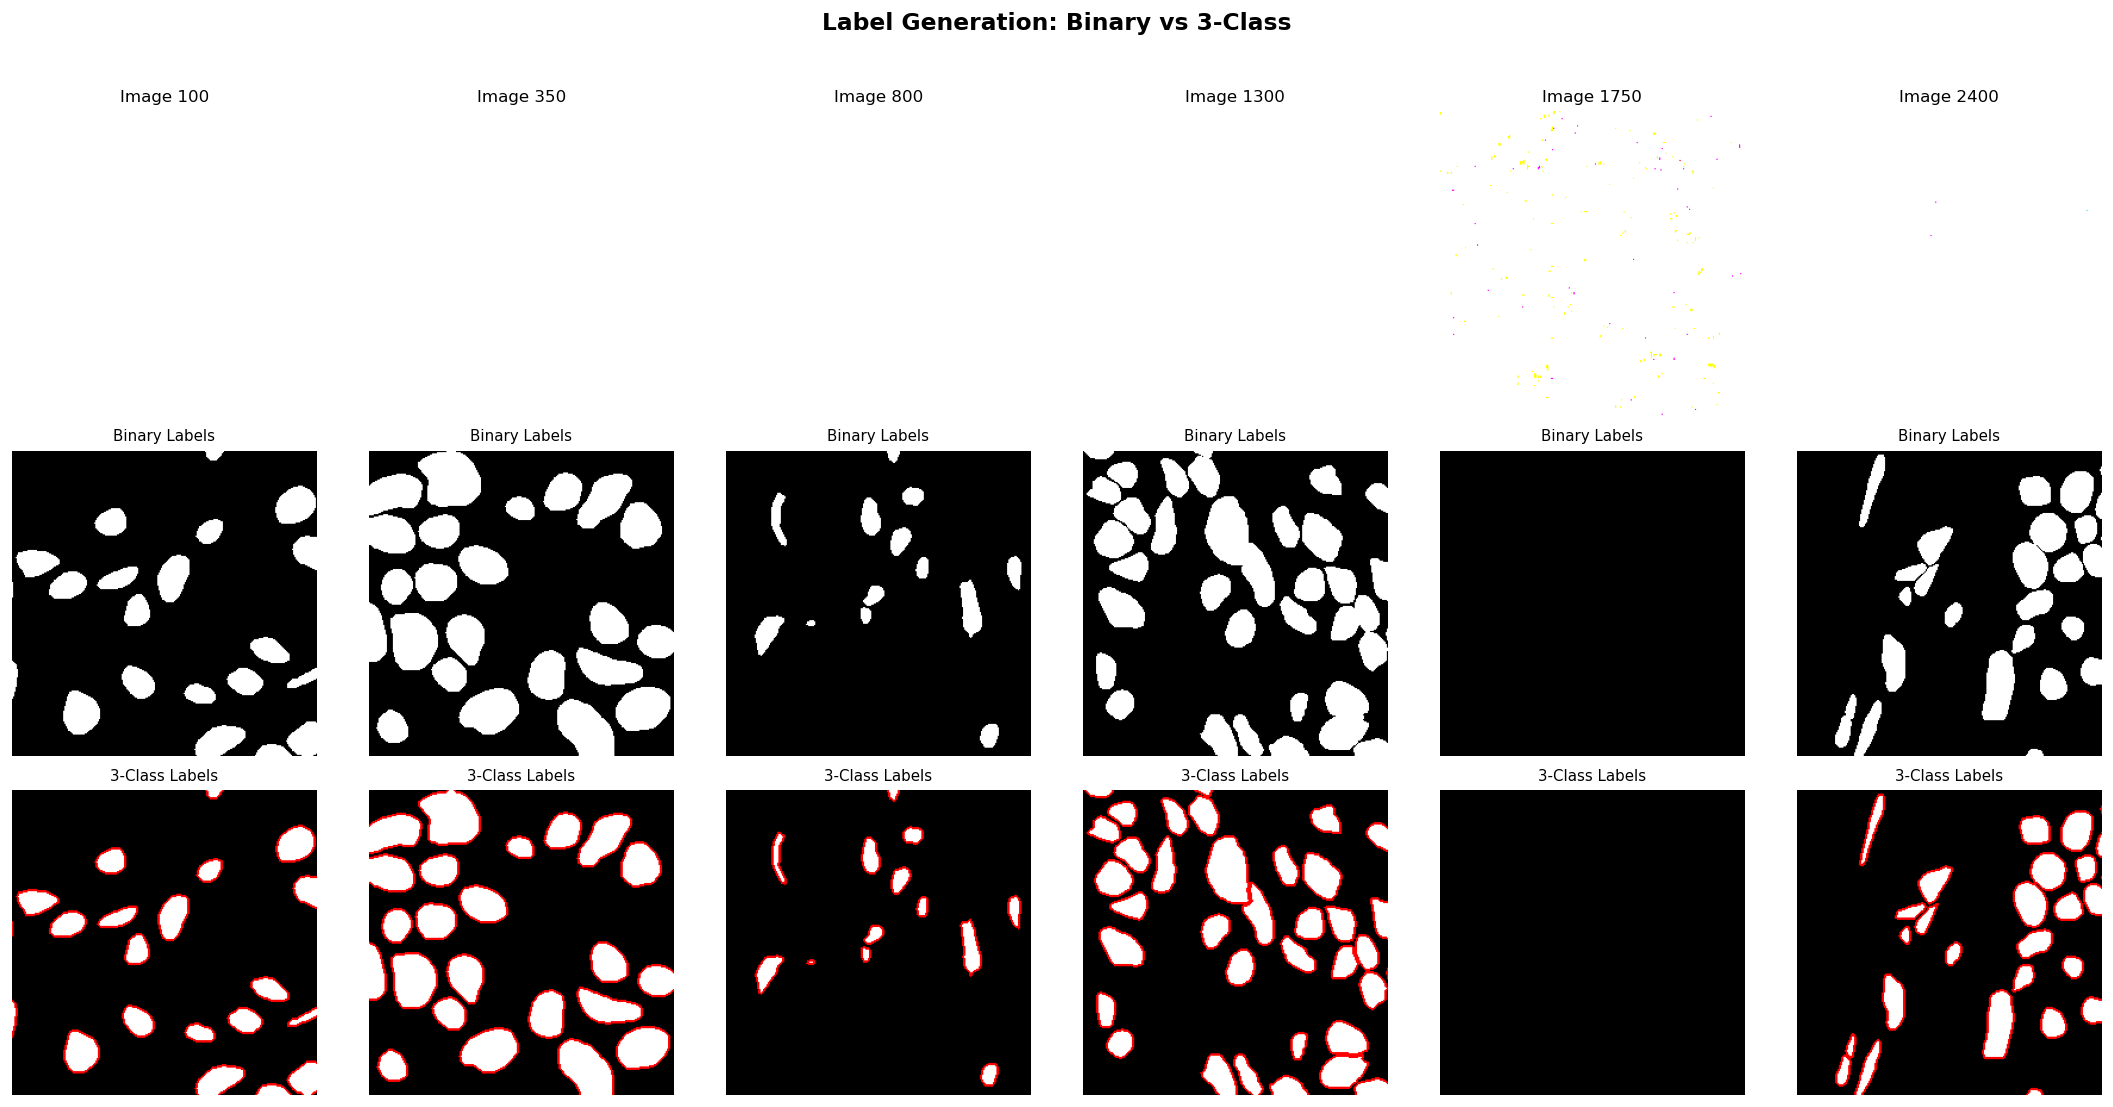

In [5]:
fig, axes = plt.subplots(3, len(sample_indices), figsize=(3*len(sample_indices), 9))
fig.suptitle('Label Generation: Binary vs 3-Class', fontsize=14, fontweight='bold', y=1.02)

for col, idx in enumerate(sample_indices):
    img = images[idx]
    mask = masks[idx]
    labels_bin = generate_binary_labels(mask)
    labels_3c  = generate_3class_labels(mask)
    
    axes[0, col].imshow(img)
    axes[0, col].set_title(f'Image {idx}', fontsize=10)
    axes[0, col].axis('off')
    
    axes[1, col].imshow(labels_bin, cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f'Binary Labels', fontsize=9)
    axes[1, col].axis('off')
    
    cmap_3c = ListedColormap(['black', 'white', 'red'])
    axes[2, col].imshow(labels_3c, cmap=cmap_3c, vmin=0, vmax=2)
    axes[2, col].set_title(f'3-Class Labels', fontsize=9)
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Binary', fontsize=11)
axes[2, 0].set_ylabel('3-Class', fontsize=11)

plt.tight_layout()
plt.show()

## 4. Distance Transform Visualization

The **distance transform** is the core of active boundary mining.  
It computes, for each background pixel, its distance to the nearest nucleus pixel.  
Pixels **close to boundaries** (distance < 10px) get **3× higher sampling probability**.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [34.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [46.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [33.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [5.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..247.0].


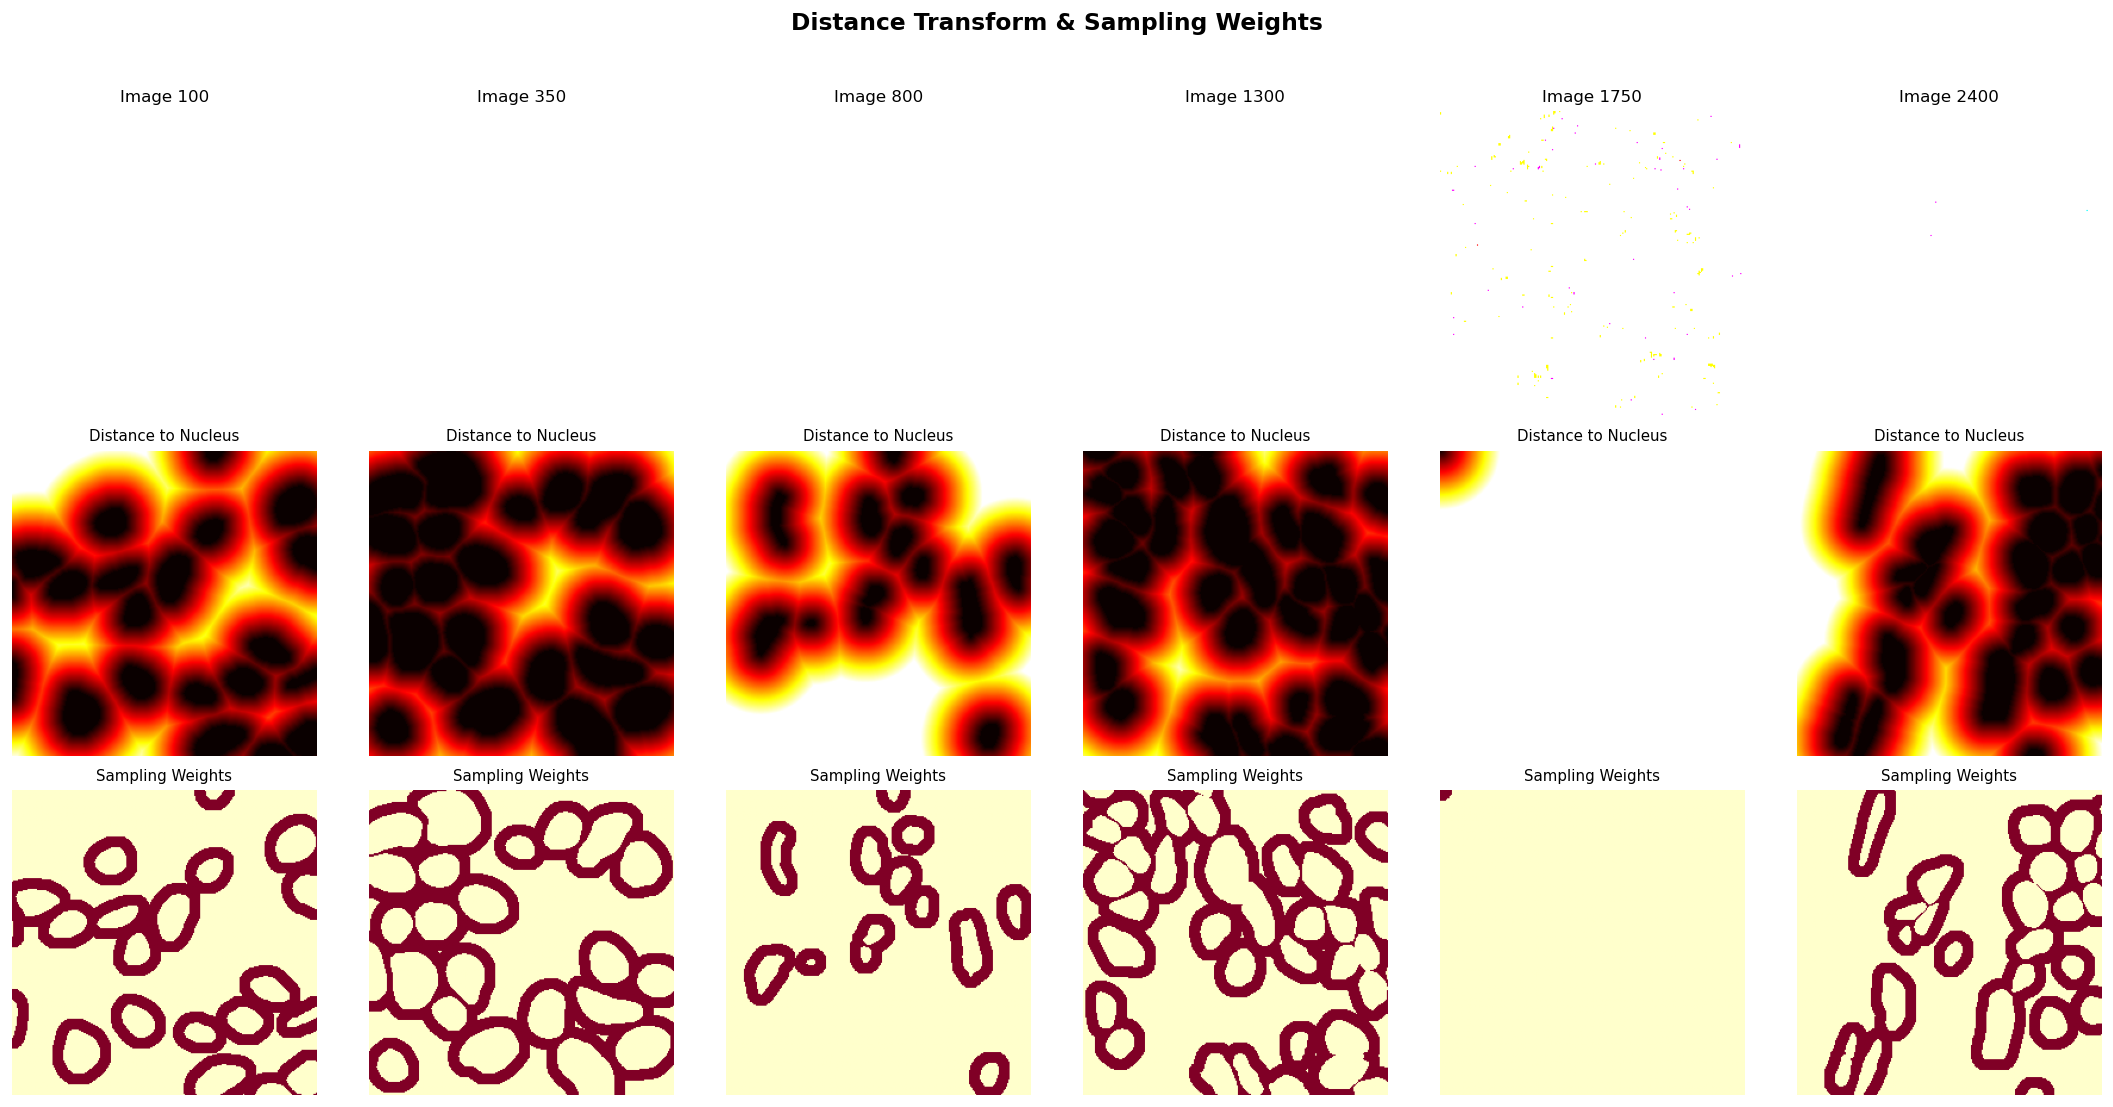

Red zones = 3x sampling boost (within 10px of nucleus boundary)


In [6]:
fig, axes = plt.subplots(3, len(sample_indices), figsize=(3*len(sample_indices), 9))
fig.suptitle('Distance Transform & Sampling Weights', fontsize=14, fontweight='bold', y=1.02)

for col, idx in enumerate(sample_indices):
    img = images[idx]
    mask = masks[idx]
    labels_bin = generate_binary_labels(mask)
    
    # Compute distance from non-nucleus to nearest nucleus
    nucleus_mask = (labels_bin > 0).astype(np.float32)
    dist = distance_transform_edt(1 - nucleus_mask)
    
    # Create weight map (boundary_boost=3 within 10px)
    weights = np.ones_like(dist)
    near_boundary = (dist < 10) & (labels_bin == 0)
    weights[near_boundary] = 3.0
    weights[labels_bin > 0] = 1.0  # nucleus pixels get normal weight
    
    axes[0, col].imshow(img)
    axes[0, col].set_title(f'Image {idx}', fontsize=10)
    axes[0, col].axis('off')
    
    im1 = axes[1, col].imshow(dist, cmap='hot', vmin=0, vmax=50)
    axes[1, col].set_title('Distance to Nucleus', fontsize=9)
    axes[1, col].axis('off')
    
    cmap_w = ListedColormap(['#1a1a2e', '#e94560'])
    axes[2, col].imshow(weights, cmap='YlOrRd', vmin=1, vmax=3)
    axes[2, col].set_title('Sampling Weights', fontsize=9)
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Distance', fontsize=11)
axes[2, 0].set_ylabel('Weights', fontsize=11)

plt.tight_layout()
plt.show()
print('Red zones = 3x sampling boost (within 10px of nucleus boundary)')

## 5. Sampled Pixels Overlay

Now let's run the actual `active_boundary_mining` function and overlay the sampled pixels on the original images. Each class is shown in a different color:
- **Blue** = Background (class 0)
- **Green** = Nucleus / Interior (class 1)
- **Red** = Boundary (class 2, 3-class mode only)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [34.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [46.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [33.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [5.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..247.0].


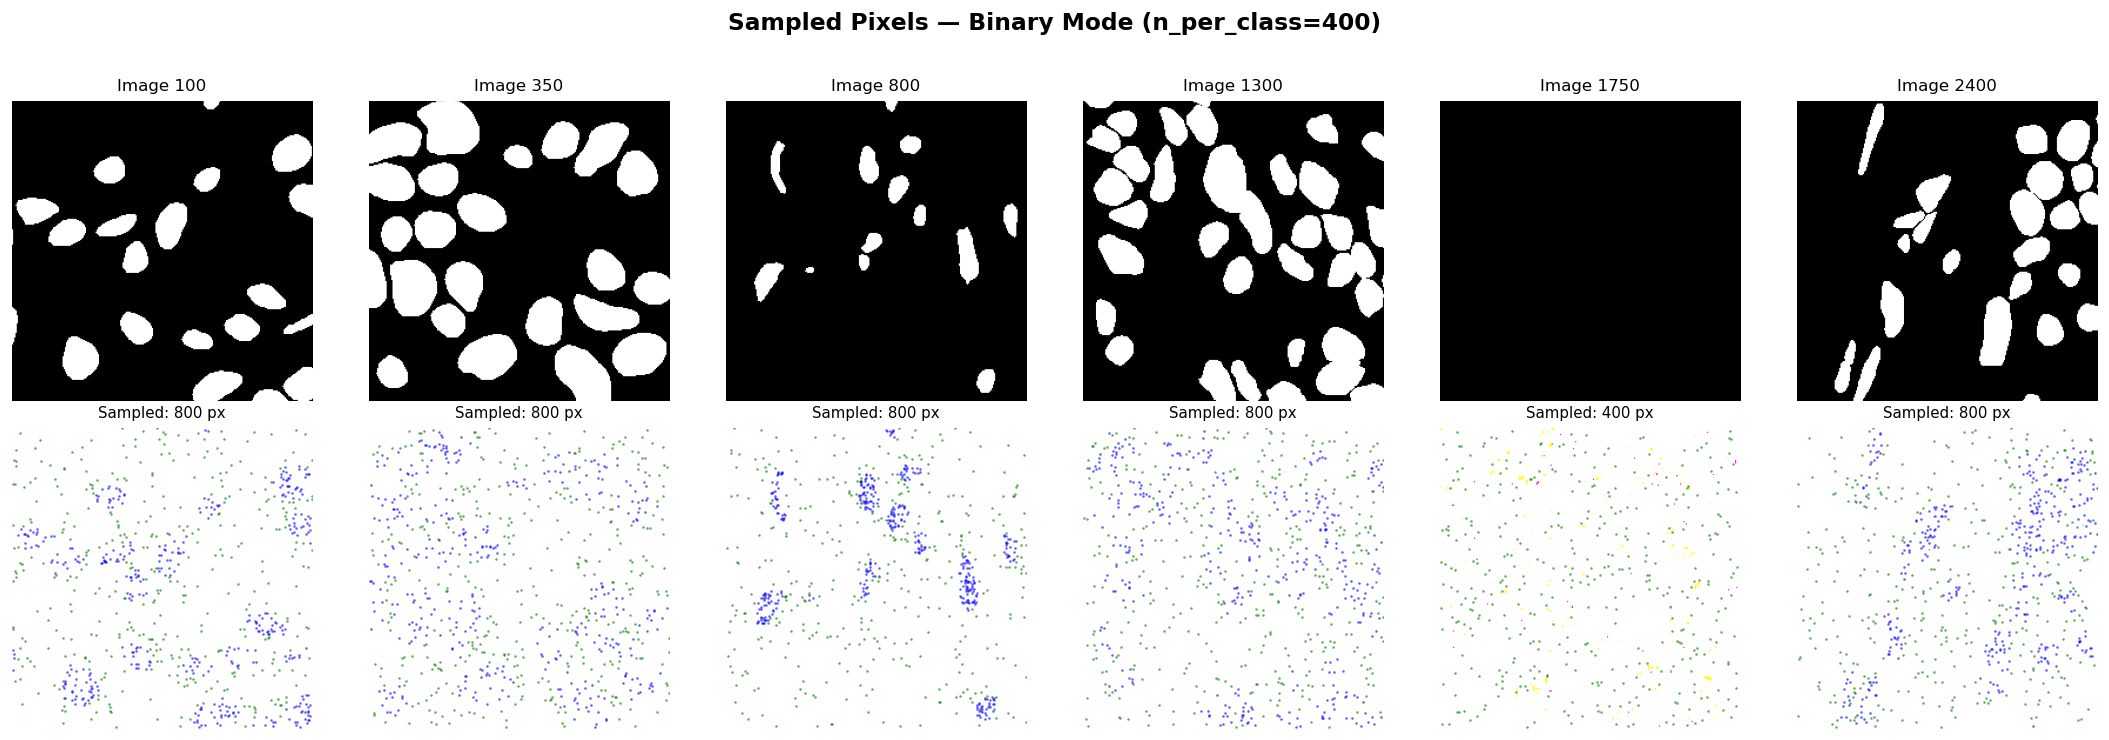

Green = background samples, Blue = nucleus samples


In [12]:
fig, axes = plt.subplots(2, len(sample_indices), figsize=(3*len(sample_indices), 6))
fig.suptitle('Sampled Pixels — Binary Mode (n_per_class=400)', fontsize=14, fontweight='bold', y=1.02)

colors_bin = {0: 'green', 1: 'blue'}

for col, idx in enumerate(sample_indices):
    img = images[idx].copy()
    mask = masks[idx]
    labels_bin = generate_binary_labels(mask)
    
    indices, sampled_labels = active_boundary_mining(labels_bin, n_per_class=400, boundary_boost=3)
    
    rows = indices // 256
    cols_px = indices % 256
    
    # Show labels
    axes[0, col].imshow(labels_bin, cmap='gray')
    axes[0, col].set_title(f'Image {idx}', fontsize=10)
    axes[0, col].axis('off')
    
    # Overlay sampled pixels
    axes[1, col].imshow(img)
    for lbl in np.unique(sampled_labels):
        m = sampled_labels == lbl
        axes[1, col].scatter(cols_px[m], rows[m], c=colors_bin[lbl], s=0.3, alpha=0.6)
    axes[1, col].set_title(f'Sampled: {len(indices)} px', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Labels', fontsize=11)
axes[1, 0].set_ylabel('Samples', fontsize=11)

plt.tight_layout()
plt.show()
print('Green = background samples, Blue = nucleus samples')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [34.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [46.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [33.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [5.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..247.0].


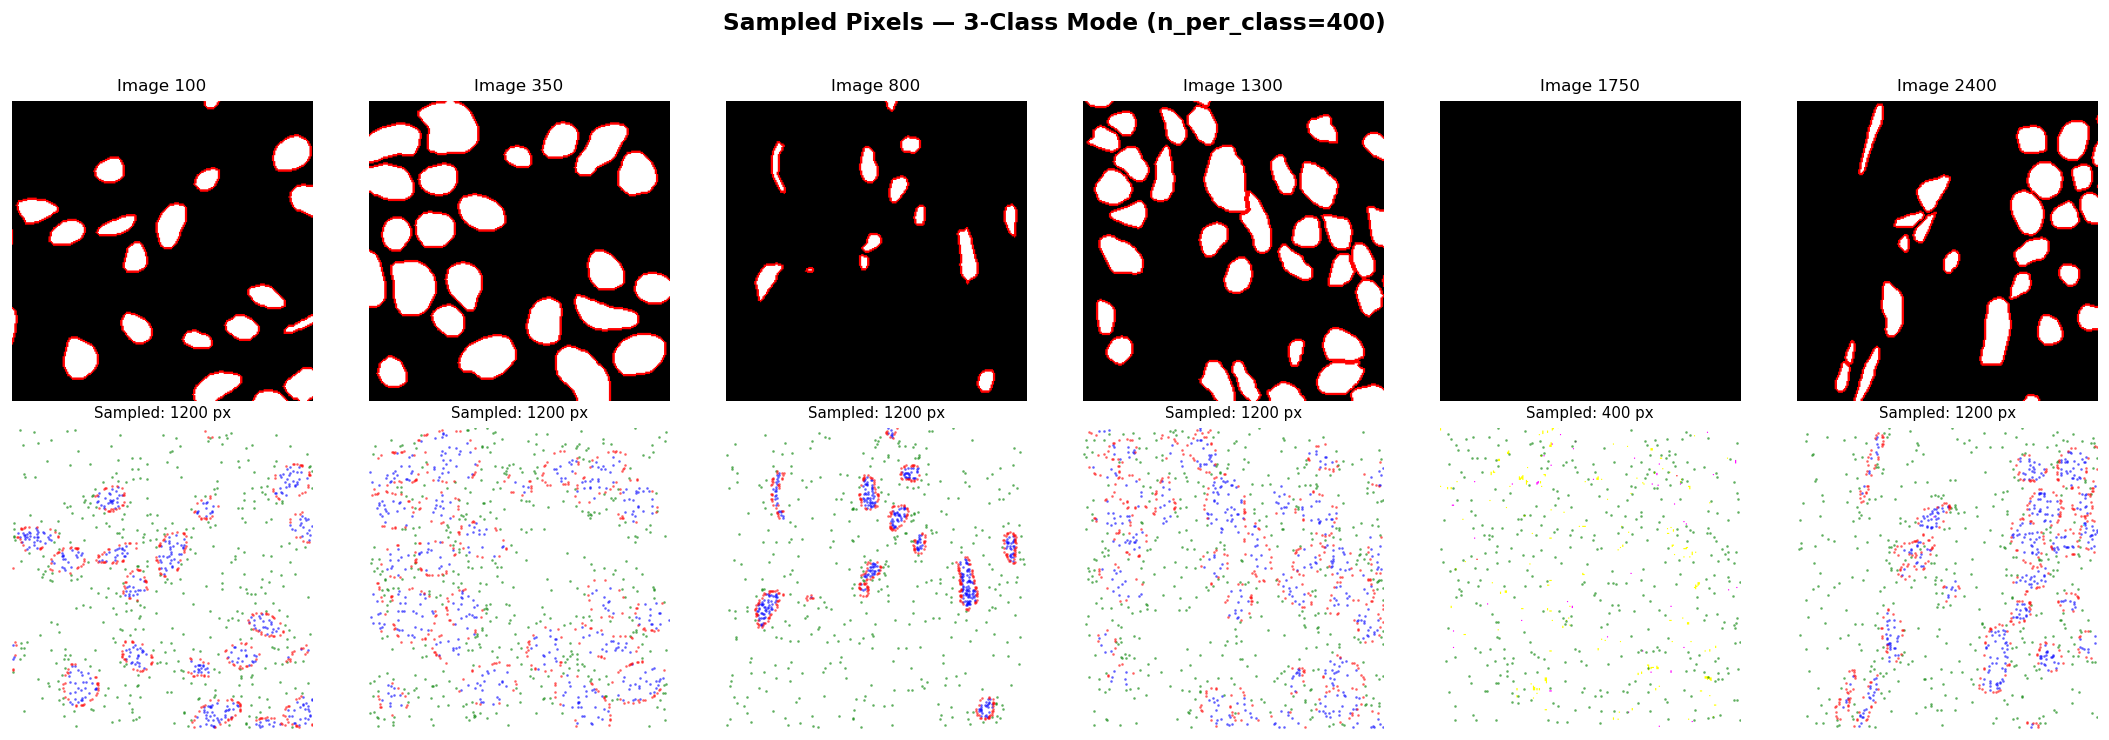

Green = background, Blue = interior, Red = boundary


In [14]:
fig, axes = plt.subplots(2, len(sample_indices), figsize=(3*len(sample_indices), 6))
fig.suptitle('Sampled Pixels — 3-Class Mode (n_per_class=400)', fontsize=14, fontweight='bold', y=1.02)

colors_3c = {0: 'green', 1: 'blue', 2: 'red'}

for col, idx in enumerate(sample_indices):
    img = images[idx].copy()
    mask = masks[idx]
    labels_3c = generate_3class_labels(mask)
    
    indices, sampled_labels = active_boundary_mining(labels_3c, n_per_class=400, boundary_boost=3)
    
    rows = indices // 256
    cols_px = indices % 256
    
    cmap_3c = ListedColormap(['black', 'white', 'red'])
    axes[0, col].imshow(labels_3c, cmap=cmap_3c, vmin=0, vmax=2)
    axes[0, col].set_title(f'Image {idx}', fontsize=10)
    axes[0, col].axis('off')
    
    axes[1, col].imshow(img)
    for lbl in np.unique(sampled_labels):
        m = sampled_labels == lbl
        axes[1, col].scatter(cols_px[m], rows[m], c=colors_3c[lbl], s=0.3, alpha=0.6)
    axes[1, col].set_title(f'Sampled: {len(indices)} px', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('3-Class', fontsize=11)
axes[1, 0].set_ylabel('Samples', fontsize=11)

plt.tight_layout()
plt.show()
print('Green = background, Blue = interior, Red = boundary')

## 6. Class Distribution Analysis

Let's check the class balance across multiple images to ensure the sampler is working correctly.

In [15]:
n_test = 100  # analyze first 100 images
class_counts_bin = {0: [], 1: []}
class_counts_3c = {0: [], 1: [], 2: []}
total_samples_bin = []
total_samples_3c = []

for i in range(n_test):
    mask = masks[i]
    
    # Binary
    labels_bin = generate_binary_labels(mask)
    idx_b, lbl_b = active_boundary_mining(labels_bin, n_per_class=400)
    total_samples_bin.append(len(idx_b))
    for c in [0, 1]:
        class_counts_bin[c].append(np.sum(lbl_b == c))
    
    # 3-Class
    labels_3c = generate_3class_labels(mask)
    idx_3, lbl_3 = active_boundary_mining(labels_3c, n_per_class=400)
    total_samples_3c.append(len(idx_3))
    for c in [0, 1, 2]:
        class_counts_3c[c].append(np.sum(lbl_3 == c))

print(f'Analyzed {n_test} images.')
print(f'\n--- Binary Mode ---')
print(f'Total samples/image: mean={np.mean(total_samples_bin):.0f}, std={np.std(total_samples_bin):.0f}')
print(f'Class 0 (bg):     mean={np.mean(class_counts_bin[0]):.0f}')
print(f'Class 1 (nuc):    mean={np.mean(class_counts_bin[1]):.0f}')
print(f'\n--- 3-Class Mode ---')
print(f'Total samples/image: mean={np.mean(total_samples_3c):.0f}, std={np.std(total_samples_3c):.0f}')
print(f'Class 0 (bg):       mean={np.mean(class_counts_3c[0]):.0f}')
print(f'Class 1 (interior): mean={np.mean(class_counts_3c[1]):.0f}')
print(f'Class 2 (boundary): mean={np.mean(class_counts_3c[2]):.0f}')

Analyzed 100 images.

--- Binary Mode ---
Total samples/image: mean=800, std=0
Class 0 (bg):     mean=400
Class 1 (nuc):    mean=400

--- 3-Class Mode ---
Total samples/image: mean=1200, std=0
Class 0 (bg):       mean=400
Class 1 (interior): mean=400
Class 2 (boundary): mean=400


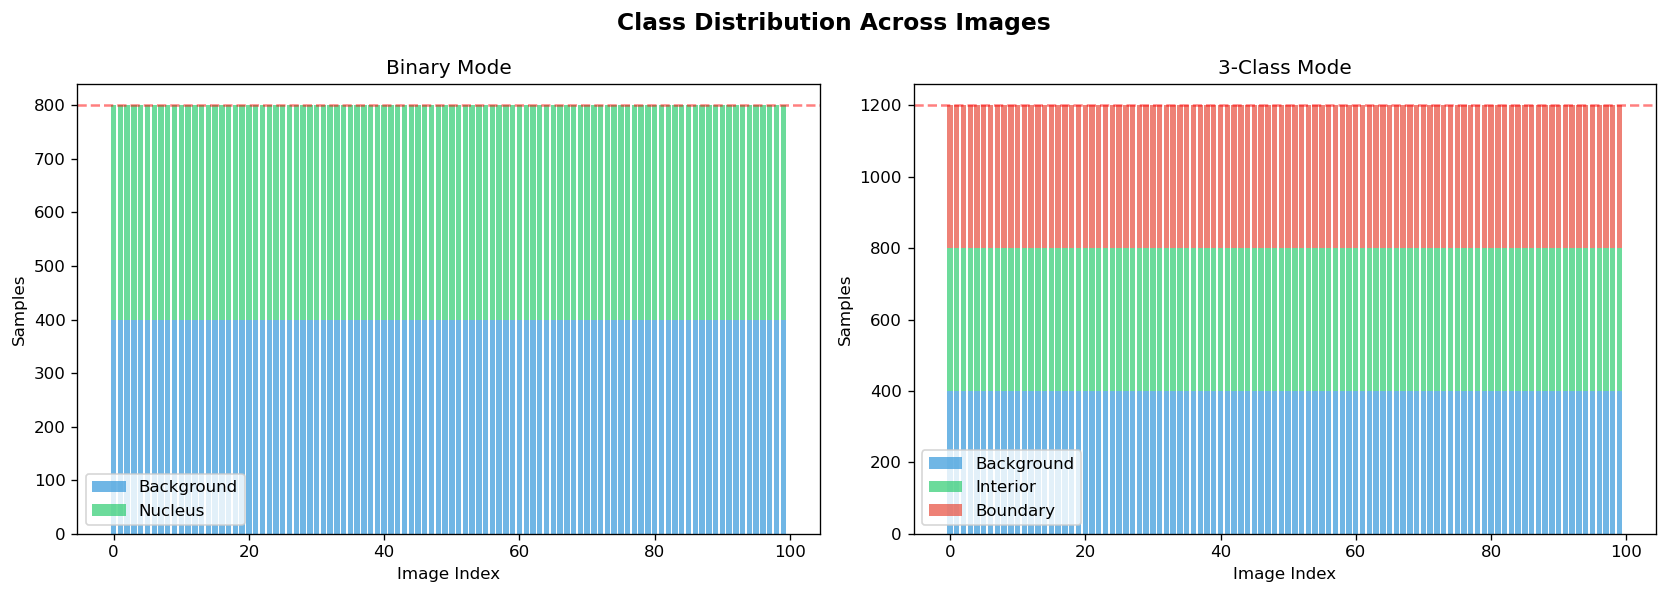

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution Across Images', fontsize=14, fontweight='bold')

# Binary
x = np.arange(n_test)
axes[0].bar(x, class_counts_bin[0], color='#3498db', alpha=0.7, label='Background')
axes[0].bar(x, class_counts_bin[1], bottom=class_counts_bin[0], color='#2ecc71', alpha=0.7, label='Nucleus')
axes[0].set_xlabel('Image Index')
axes[0].set_ylabel('Samples')
axes[0].set_title('Binary Mode')
axes[0].legend()
axes[0].axhline(y=800, color='red', linestyle='--', alpha=0.5, label='Target (2×400)')

# 3-Class
b0 = np.array(class_counts_3c[0])
b1 = np.array(class_counts_3c[1])
b2 = np.array(class_counts_3c[2])
axes[1].bar(x, b0, color='#3498db', alpha=0.7, label='Background')
axes[1].bar(x, b1, bottom=b0, color='#2ecc71', alpha=0.7, label='Interior')
axes[1].bar(x, b2, bottom=b0+b1, color='#e74c3c', alpha=0.7, label='Boundary')
axes[1].set_xlabel('Image Index')
axes[1].set_ylabel('Samples')
axes[1].set_title('3-Class Mode')
axes[1].legend()
axes[1].axhline(y=1200, color='red', linestyle='--', alpha=0.5, label='Target (3×400)')

plt.tight_layout()
plt.show()

## 7. Boundary Boost Effect

Let's compare the spatial distribution of background samples **with** and **without** boundary boosting.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [33.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [33.0..255.0].


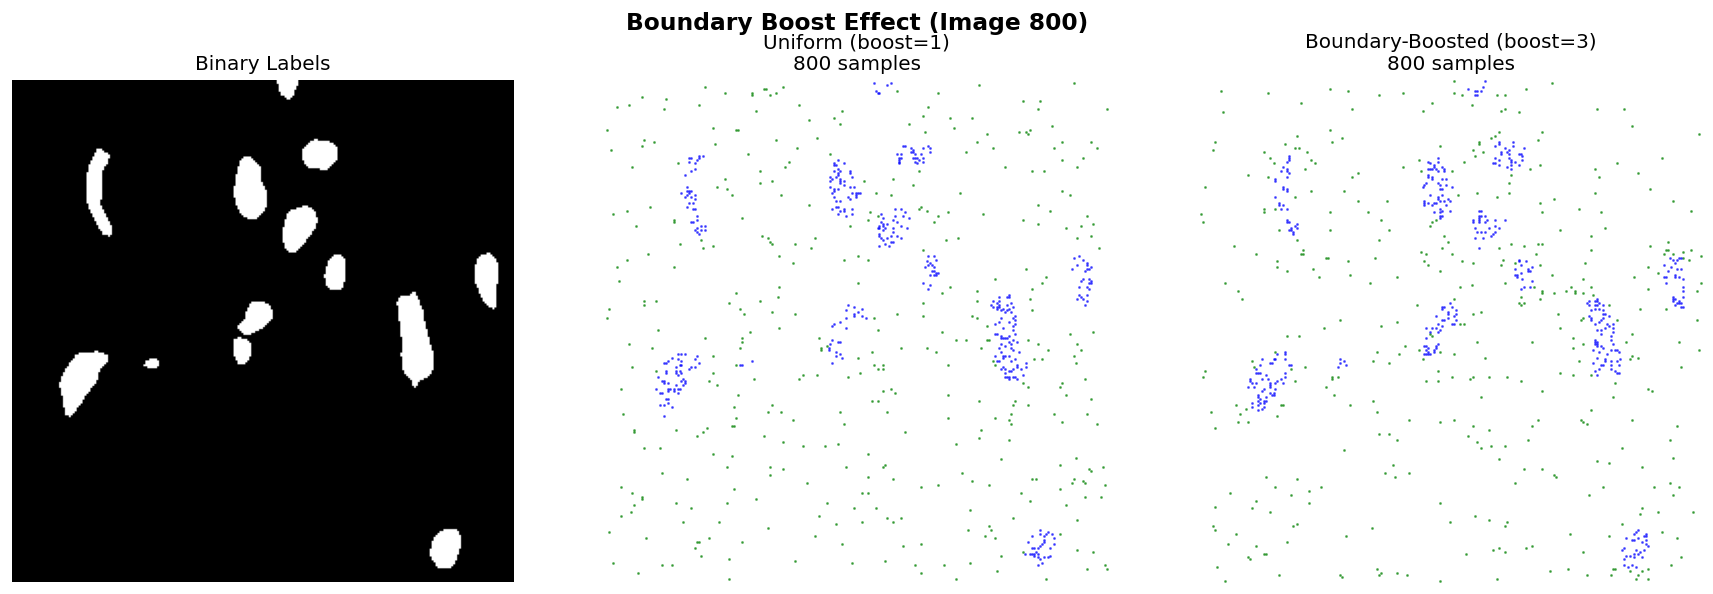

Notice: with boundary boost, cyan (background) dots cluster near nucleus edges.
This forces the classifier to learn the hardest decision boundary.


In [22]:
test_idx = sample_indices[2]  # pick one image
img = images[test_idx].copy()
mask = masks[test_idx]
labels = generate_binary_labels(mask)

# Boundary-boosted sampling
idx_boost, lbl_boost = active_boundary_mining(labels, n_per_class=400, boundary_boost=3)

# Uniform sampling (boost=1 means no boost)
idx_uniform, lbl_uniform = active_boundary_mining(labels, n_per_class=400, boundary_boost=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Boundary Boost Effect (Image {test_idx})', fontsize=14, fontweight='bold')

axes[0].imshow(labels, cmap='gray')
axes[0].set_title('Binary Labels')
axes[0].axis('off')

# Uniform
axes[1].imshow(img)
bg_mask = lbl_uniform == 0
nuc_mask = lbl_uniform == 1
axes[1].scatter(idx_uniform[bg_mask] % 256, idx_uniform[bg_mask] // 256, c='green', s=0.5, alpha=0.6)
axes[1].scatter(idx_uniform[nuc_mask] % 256, idx_uniform[nuc_mask] // 256, c='blue', s=0.5, alpha=0.6)
axes[1].set_title(f'Uniform (boost=1)\n{len(idx_uniform)} samples')
axes[1].axis('off')

# Boundary-boosted
axes[2].imshow(img)
bg_mask = lbl_boost == 0
nuc_mask = lbl_boost == 1
axes[2].scatter(idx_boost[bg_mask] % 256, idx_boost[bg_mask] // 256, c='green', s=0.5, alpha=0.6)
axes[2].scatter(idx_boost[nuc_mask] % 256, idx_boost[nuc_mask] // 256, c='blue', s=0.5, alpha=0.6)
axes[2].set_title(f'Boundary-Boosted (boost=3)\n{len(idx_boost)} samples')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print('Notice: with boundary boost, cyan (background) dots cluster near nucleus edges.')
print('This forces the classifier to learn the hardest decision boundary.')

## 8. Summary

### Key Findings:
- **Active Boundary Mining** oversamples background pixels within 10px of nucleus boundaries at 3× higher rate
- **Binary mode** produces ~800 samples/image (400 per class × 2 classes)
- **3-Class mode** produces ~1,200 samples/image (400 per class × 3 classes)
- Images with sparse nuclei may produce fewer than target samples (handled by truncation in streaming_loader)
- Boundary-boosted sampling concentrates hard examples near decision boundaries

### Pipeline Integration:
- Sampling happens **after** dense feature extraction (87 features)
- GLCM (6 features) is computed **per-sampled-pixel** on the 15×15 patch
- Final per-sample vector: 87 + 6 = **93 features**